# Plot: treatment importance by patient

Loads the same per-patient ANOVA fits and plots the mean `treatment` share of variance for each patient.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from notebook_init_utils import init_notebook

warnings.filterwarnings("ignore")
root_dir, in_notebook = init_notebook()

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)

figures_path = pathlib.Path(
    root_dir, "4.linear_modeling/figures/per_patient_variate_importance"
)
figures_path.mkdir(parents=True, exist_ok=True)
results_path = pathlib.Path(
    root_dir, "4.linear_modeling/results/per_patient_variate_importance"
)

anova_dfs = {
    name: pd.read_parquet(results_path / f"{name}_per_patient_anova.parquet")
    for name in ["organoid", "single_cell"]
}

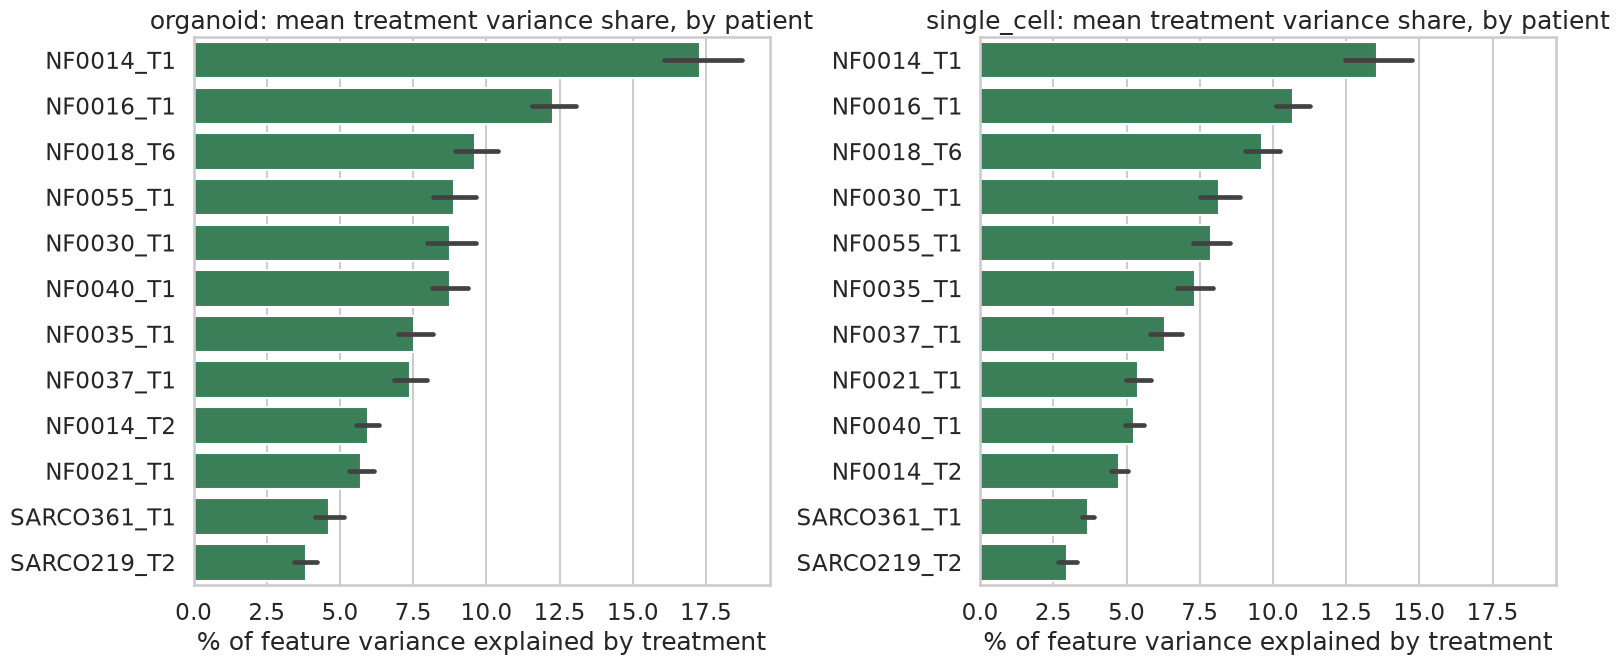

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)
for ax, (name, pdf) in zip(axes, anova_dfs.items()):
    trt = pdf[pdf["term"] == "treatment"]
    order = (
        trt.groupby("patient")["pct_variance_explained"]
        .mean()
        .sort_values(ascending=False)
        .index
    )
    sns.barplot(
        data=trt,
        y="patient",
        x="pct_variance_explained",
        order=order,
        ax=ax,
        color="seagreen",
    )
    ax.set_title(f"{name}: mean treatment variance share, by patient")
    ax.set_xlabel("% of feature variance explained by treatment")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(
    figures_path / "treatment_importance_by_patient.png", dpi=600, bbox_inches="tight"
)
plt.show()

Patients where treatment explains more of the variance are the ones where morphology is most drug-responsive; low-treatment-share patients are ones where drug identity barely matters relative to well-to-well noise and density.